In [1]:
import pandas as pd

In [2]:
url_recrutamento = "https://raw.githubusercontent.com/JulianaMoretto/Postech-data-analytics/refs/heads/main/Machine-Learning/Recrutamento.xlsx"

In [3]:
recrutamento = pd.read_excel(url_recrutamento)
recrutamento.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Yes,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Yes,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Yes,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,No,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Yes,425000.0


In [4]:
recrutamento.shape

(215, 15)

Variável Target: No nosso case a target é a coluna status.

In [5]:
set(recrutamento.status)

{'No', 'Yes'}

In [6]:
recrutamento.describe()

,sl_no,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
count,215.000000,215.000000,215.000000,215.000000,215.000000,215.000000,148.000000
mean,108.000000,67.303395,66.333163,66.370186,72.100558,62.278186,288655.405405
std,62.209324,10.827205,10.897509,7.358743,13.275956,5.833385,93457.452420
min,1.000000,40.890000,37.000000,50.000000,50.000000,51.210000,200000.000000
25%,54.500000,60.600000,60.900000,61.000000,60.000000,57.945000,240000.000000
50%,108.000000,67.000000,65.000000,66.000000,71.000000,62.000000,265000.000000
75%,161.500000,75.700000,73.000000,72.000000,83.500000,66.255000,300000.000000
max,215.000000,89.400000,97.700000,91.000000,98.000000,77.890000,940000.000000


Inferência sobre os dados:

Métricas de pontuação sobre ensino: ssc_p hsc_p degree_p estet_p mba_p

sl_no é um código, então não faz sentido na análise.

salary vem após a contratação.

<Axes: >

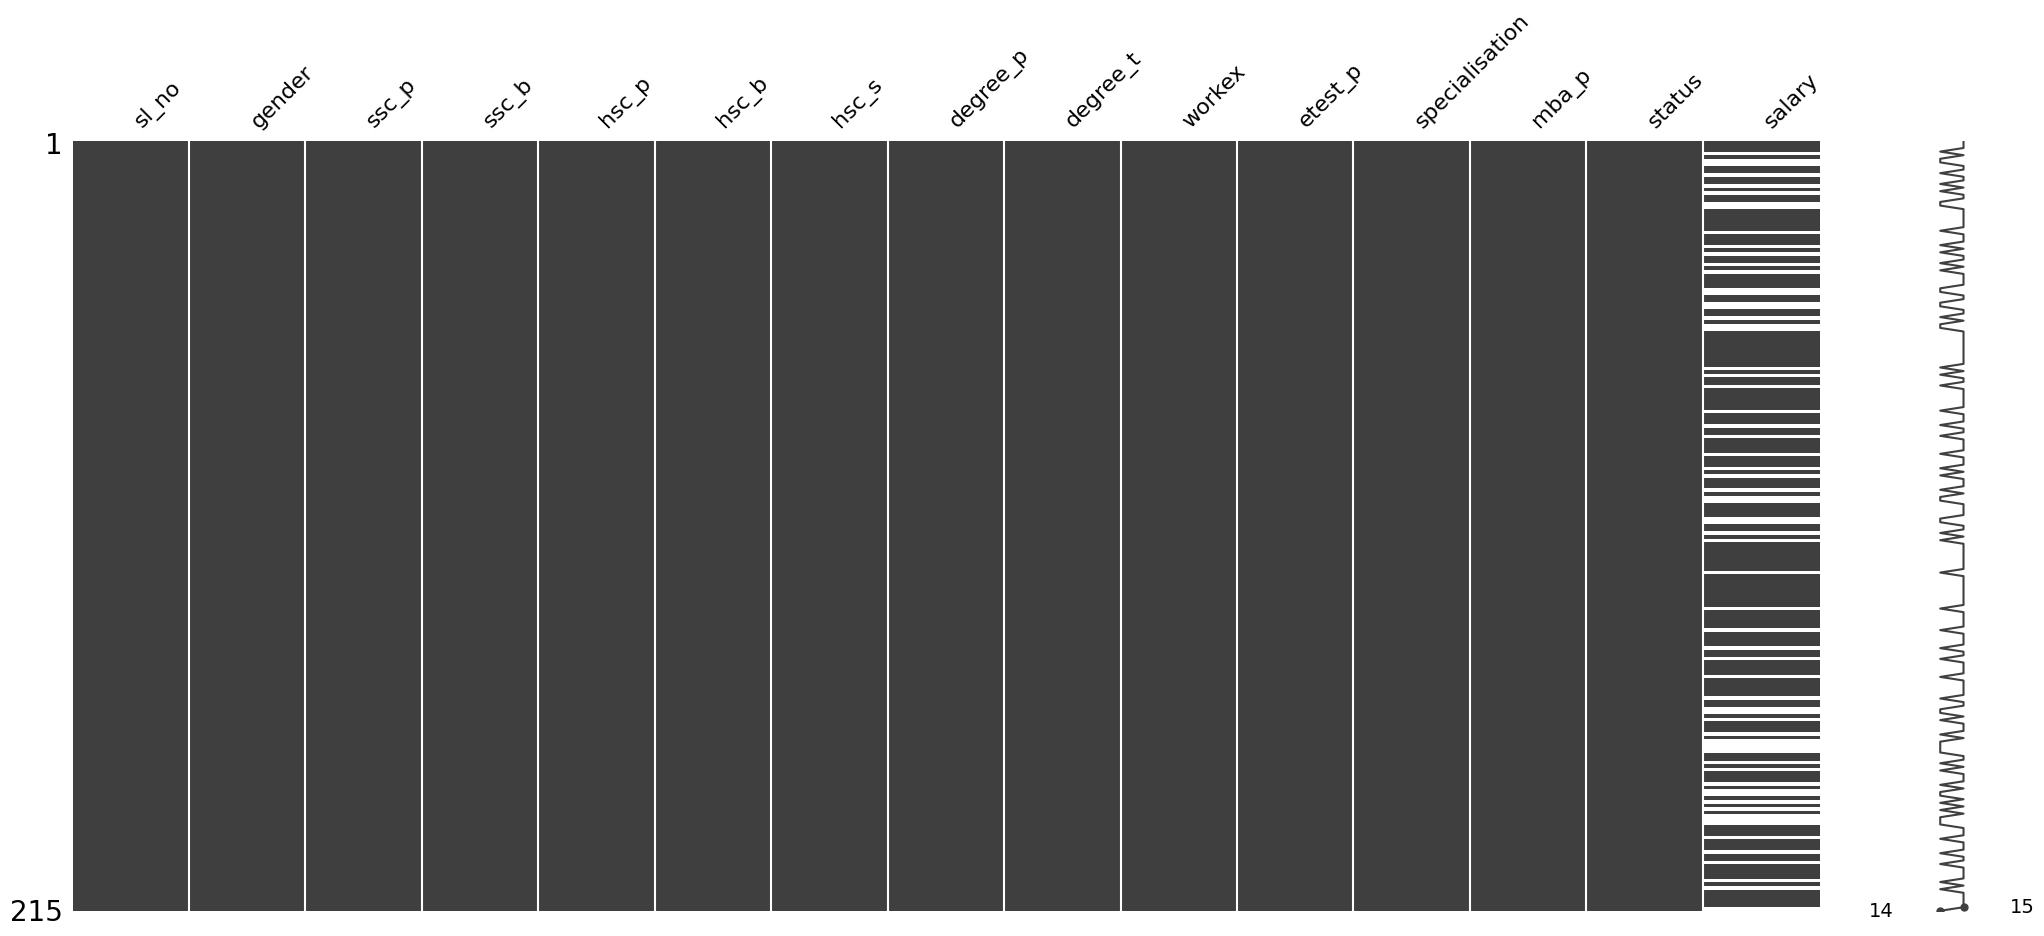

In [7]:
import missingno as msno
msno.matrix(recrutamento)

In [8]:
recrutamento.isnull().sum()

,0
sl_no,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0


In [9]:
import seaborn as sns

<Axes: xlabel='status', ylabel='salary'>

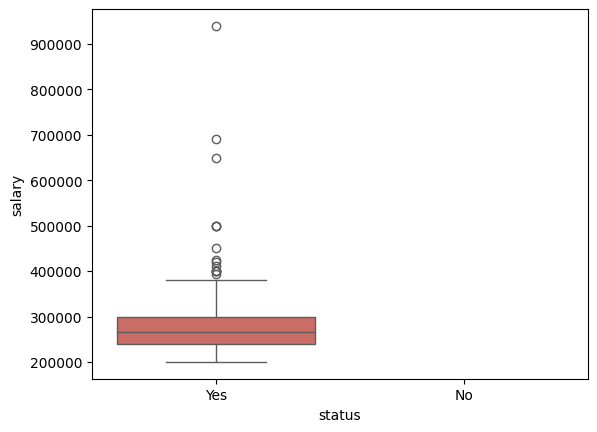

In [10]:
sns.boxplot(x="status",y="salary",data=recrutamento,palette="hls",hue="status")

In [11]:
recrutamento['salary'].fillna(value=0, inplace=True)

/tmp/ipython-input-671824522.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  recrutamento['salary'].fillna(value=0, inplace=True)


In [12]:
recrutamento.isnull().sum()

,0
sl_no,0
gender,0
ssc_p,0
ssc_b,0
hsc_p,0
hsc_b,0
hsc_s,0
degree_p,0
degree_t,0
workex,0


<Axes: xlabel='hsc_p'>

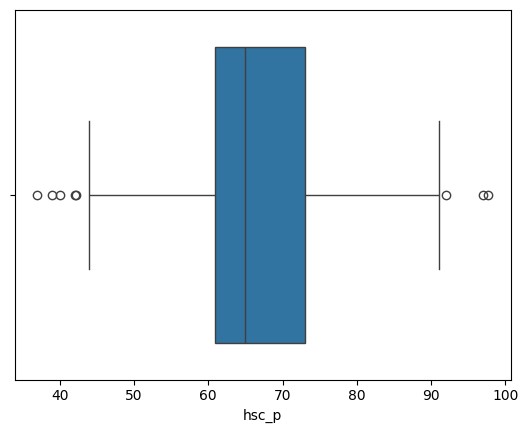

In [13]:
sns.boxplot(x="hsc_p",data=recrutamento)

<Axes: xlabel='hsc_p', ylabel='Count'>

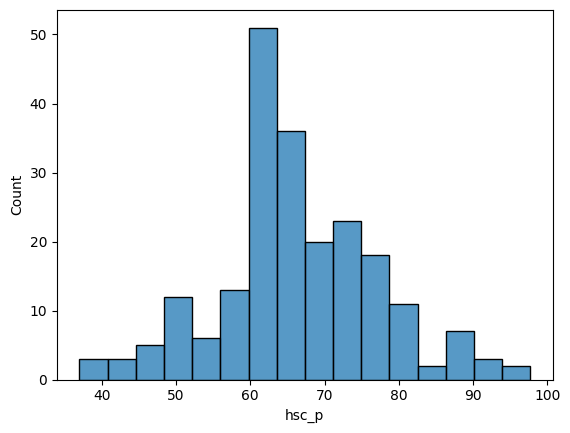

In [14]:
sns.histplot(x="hsc_p",data=recrutamento)

<Axes: xlabel='degree_p'>

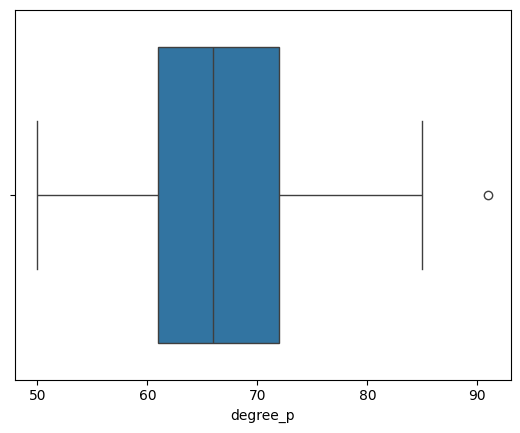

In [15]:
sns.boxplot(x="degree_p",data=recrutamento)

<Axes: xlabel='degree_p', ylabel='Count'>

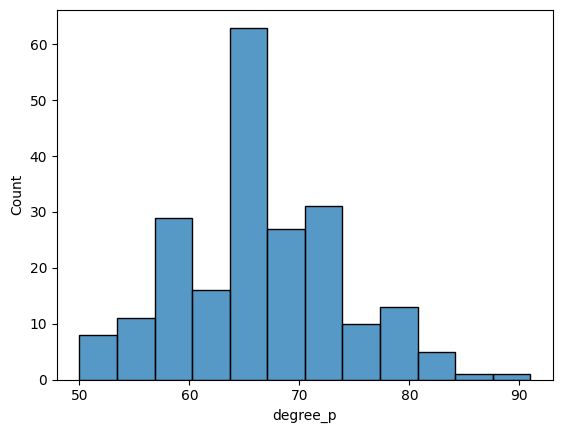

In [16]:
sns.histplot(x="degree_p",data=recrutamento)

<Axes: xlabel='etest_p'>

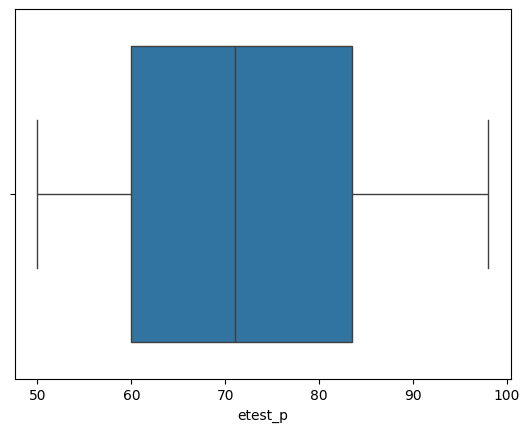

In [17]:
sns.boxplot(x="etest_p",data=recrutamento)

<Axes: xlabel='etest_p', ylabel='Count'>

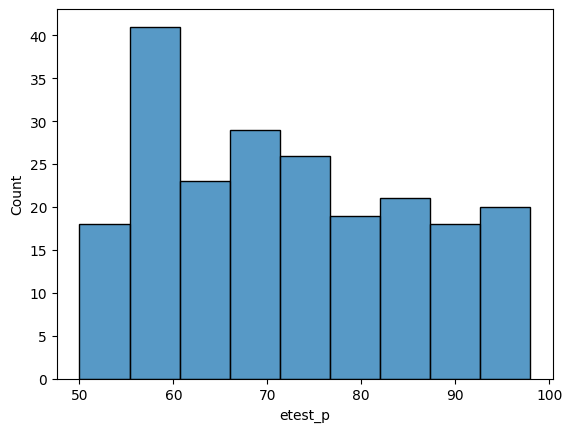

In [18]:
sns.histplot(x="etest_p",data=recrutamento)

<Axes: xlabel='mba_p'>

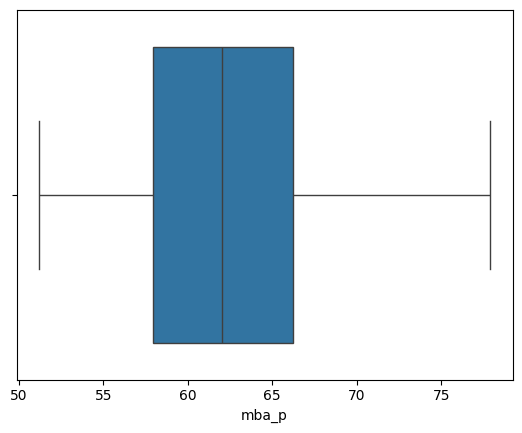

In [19]:
sns.boxplot(x="mba_p",data=recrutamento)

<Axes: xlabel='mba_p', ylabel='Count'>

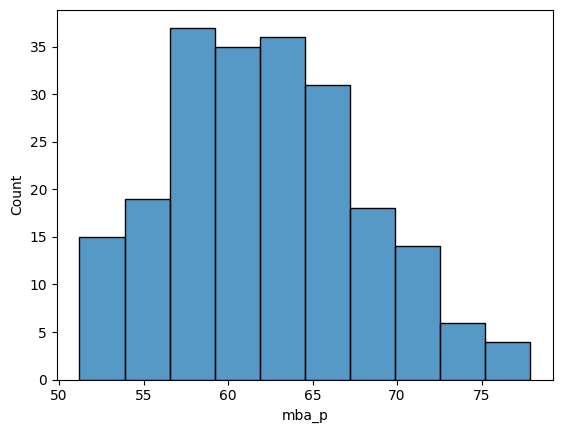

In [20]:
sns.histplot(x="mba_p",data=recrutamento)

<Axes: xlabel='salary'>

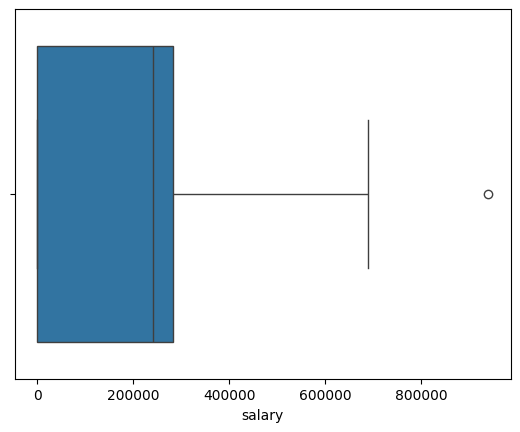

In [21]:
sns.boxplot(x="salary",data=recrutamento)

Possível ver grande discrepância. Maior parte dos dados está até 200k, e a média um pouco acima dos 200k.
além disso, temos um outlier, de alguém com um salário maior a 800k

<Axes: xlabel='salary', ylabel='Count'>

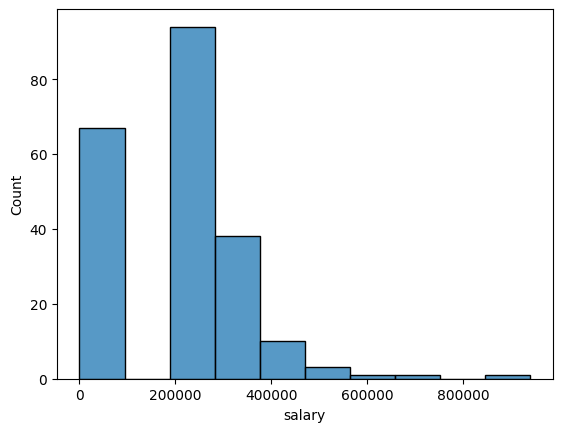

In [22]:
sns.histplot(x="salary",data=recrutamento)

Será que os scores acadêmicos influenciam na contratação? E a experiência de trabalho?

[Text(36.5, 0.5, '')]

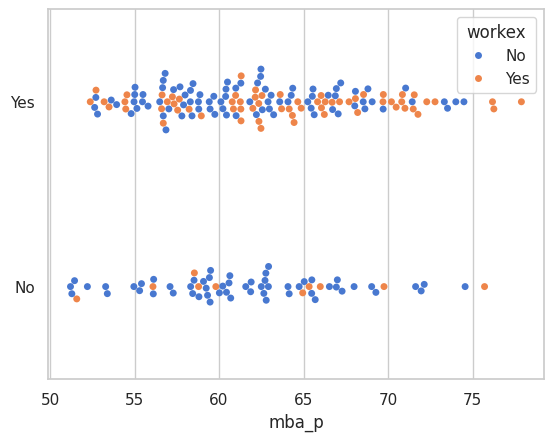

In [23]:
sns.set_theme(style="whitegrid",palette="muted")
ax = sns.swarmplot(data=recrutamento,x="mba_p",y="status",hue="workex")
ax.set(ylabel="")

Podemos observar que a pontuação de MBA pode influência sim na decisão de contratação, temos um grande concetração de dados sobre profissionais que possuem score de mba_p e com esperiência de trabalho.

In [24]:
! pip install plotly_express

In [25]:
import plotly_express as px

In [26]:
px.violin(recrutamento, y="salary", x="specialisation",color="gender",box=True,points="all")

Os maiores salários foram dados aos homens. O salário médio oferecido também foi maior para homens.

In [27]:
px.violin(recrutamento, y="mba_p", x="status",color="gender",box=True,points="all")

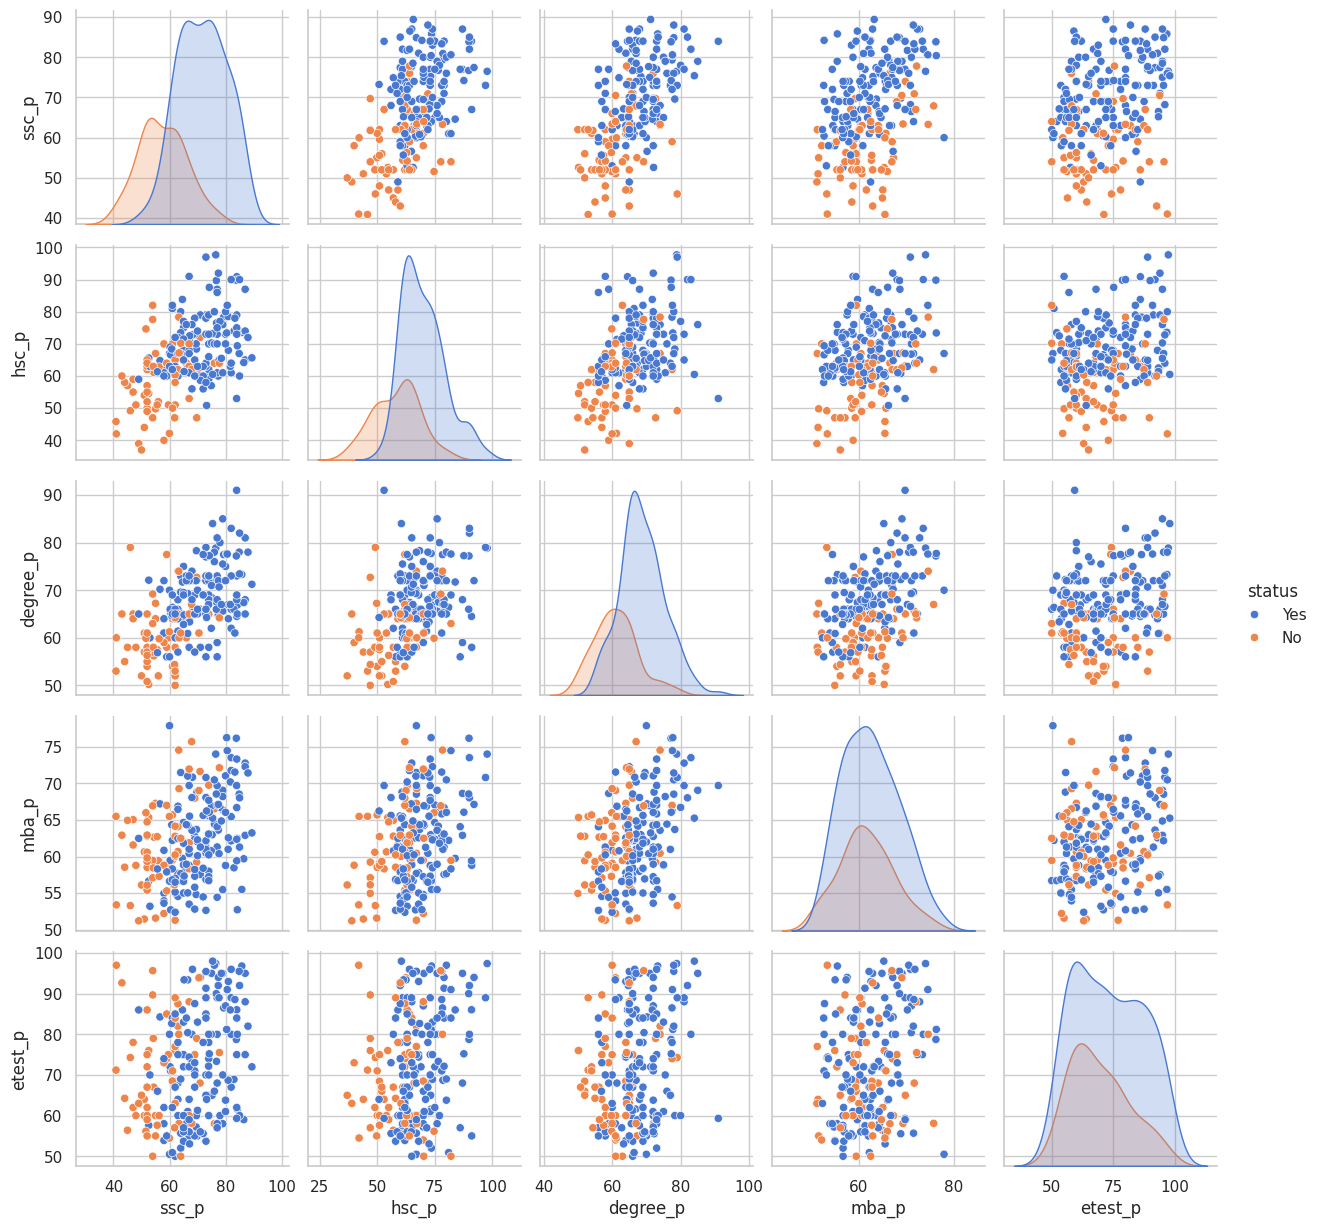

In [28]:
sns.pairplot(recrutamento,vars=['ssc_p','hsc_p','degree_p','mba_p','etest_p'],hue="status")

In [29]:
import matplotlib.pyplot as plt
%matplotlib inline

<Axes: >

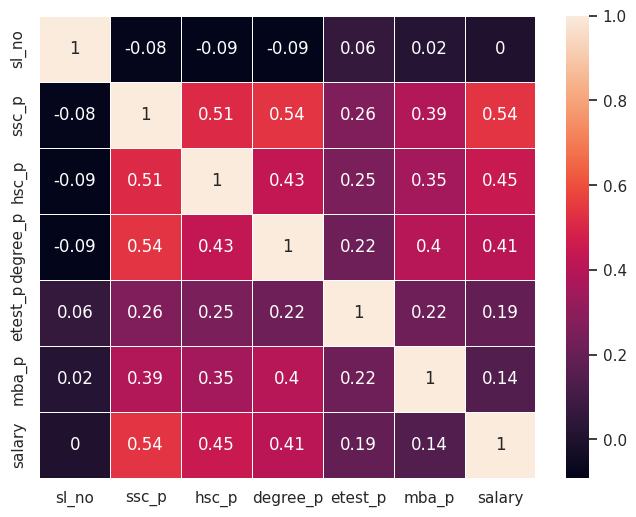

In [30]:
correlation_matrix = recrutamento.select_dtypes(include="number").corr().round(2)
fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(data=correlation_matrix,annot=True,linewidths=.5,ax=ax)

Aqui somente conseguimos analisar a correlação entre as variáveis numéricas. Com isso, é importante transformar os outros dados para variável numérica.

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
colunas = ["gender","workex","specialisation","status"]
label_encoder = LabelEncoder()
for col in colunas:
  recrutamento[col] = label_encoder.fit_transform(recrutamento[col])

In [33]:
recrutamento.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,1,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,0,55.0,1,58.80,1,270000.0
1,2,1,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,1,86.5,0,66.28,1,200000.0
2,3,1,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,0,75.0,0,57.80,1,250000.0
3,4,1,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,0,66.0,1,59.43,0,0.0
4,5,1,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,0,96.8,0,55.50,1,425000.0


<Axes: >

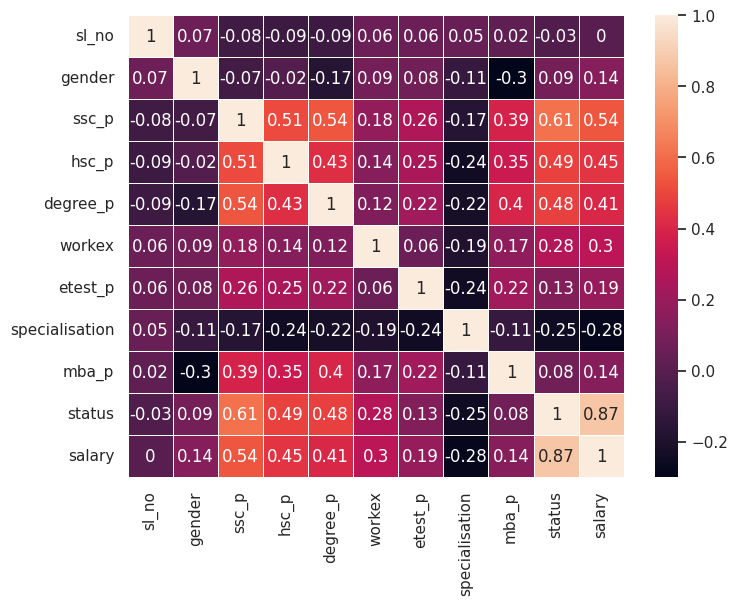

In [34]:
correlation_matrix = recrutamento.select_dtypes(include="number").corr().round(2)
fig,ax = plt.subplots(figsize=(8,6))
sns.heatmap(data=correlation_matrix,annot=True,linewidths=.5,ax=ax)

In [35]:
dummy_hsc_s=pd.get_dummies(recrutamento['hsc_s'], prefix='dummy')
dummy_hsc_s = dummy_hsc_s.astype(int)
dummy_degree_t=pd.get_dummies(recrutamento['degree_t'], prefix='dummy')
dummy_degree_t = dummy_hsc_s.astype(int)
dados_coeded = pd.concat([recrutamento,dummy_hsc_s,dummy_degree_t],axis=1)
dados_coeded.drop(['hsc_s','degree_t','salary'],axis=1, inplace=True)
dados_coeded.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,degree_p,workex,etest_p,specialisation,mba_p,status,dummy_Arts,dummy_Commerce,dummy_Science,dummy_Arts,dummy_Commerce,dummy_Science
0,1,1,67.00,Others,91.00,Others,58.00,0,55.0,1,58.80,1,0,1,0,0,1,0
1,2,1,79.33,Central,78.33,Others,77.48,1,86.5,0,66.28,1,0,0,1,0,0,1
2,3,1,65.00,Central,68.00,Central,64.00,0,75.0,0,57.80,1,1,0,0,1,0,0
3,4,1,56.00,Central,52.00,Central,52.00,0,66.0,1,59.43,0,0,0,1,0,0,1
4,5,1,85.80,Central,73.60,Central,73.30,0,96.8,0,55.50,1,0,1,0,0,1,0


<Axes: >

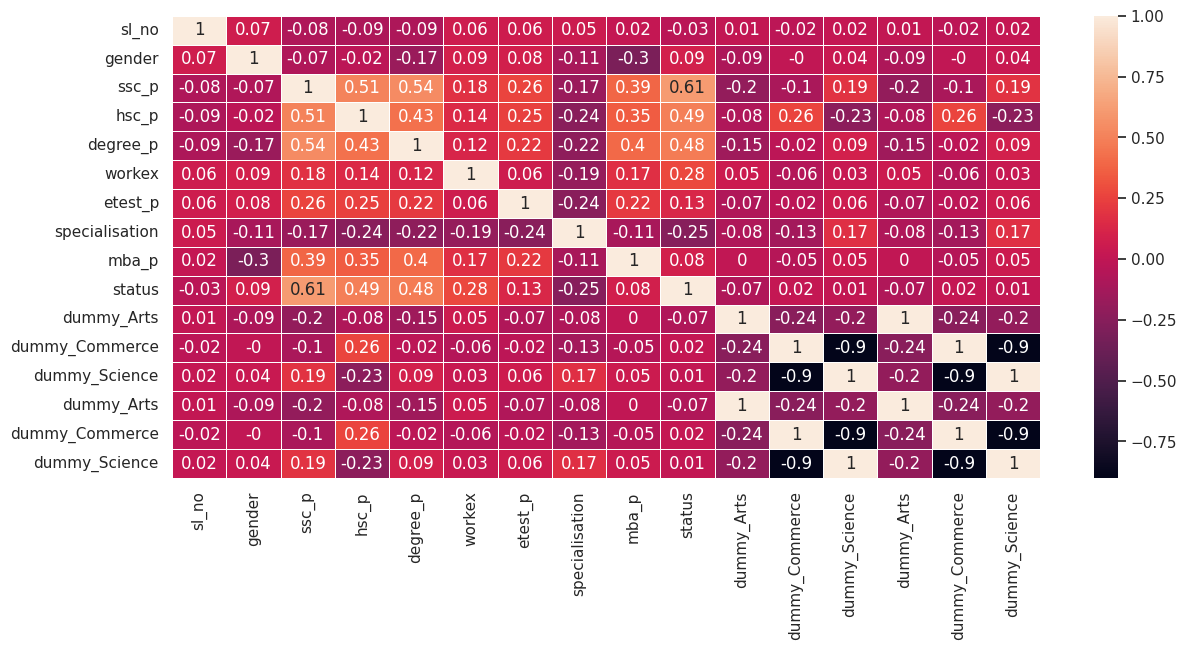

In [36]:
correlation_matrix = dados_coeded.select_dtypes(include="number").corr().round(2)
fig,ax = plt.subplots(figsize=(14,6))
sns.heatmap(data=correlation_matrix,annot=True,linewidths=.5,ax=ax)

Analisando algumas variáveis e sua correlação com a variável status, podemos identificar que as variáveis workex, degree_p, hsc_p e ssc_p possuem uma correlação interessante na contratação.

A maior correlação de status de contratação está com o score de ssc_p, ou seja, pessoas com alto score de ssc_p são mais contratadas.

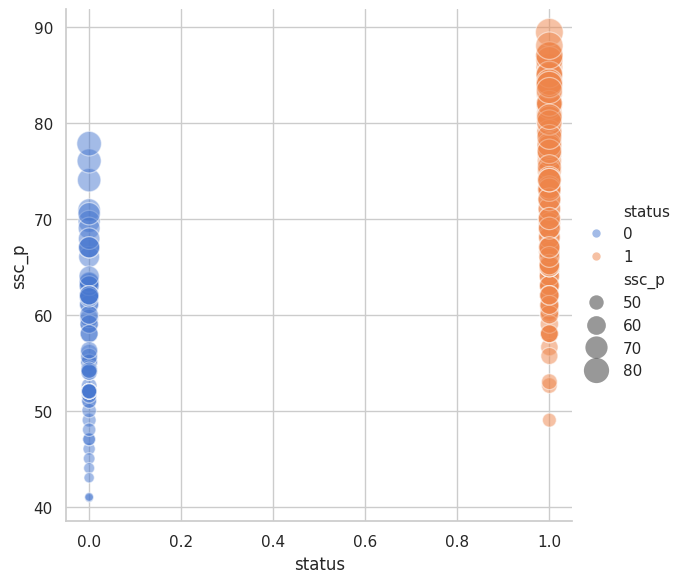

In [37]:
sns.relplot(x="status",y="ssc_p",hue="status",size="ssc_p",sizes=(40,400),alpha=.5,palette="muted",height=6,data=dados_coeded)

In [38]:
x = dados_coeded[['ssc_p', 'hsc_p', 'degree_p', 'workex', 'mba_p']] #variaveis independentes
y = dados_coeded['status'] #target

In [39]:
from sklearn.model_selection import train_test_split #separação em treino e teste
from sklearn.neighbors import KNeighborsClassifier   #knn

In [40]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=7)

In [41]:
x_train.shape

(172, 5)

In [42]:
x_test.shape

(43, 5)

In [43]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [44]:
scaler = StandardScaler()
scaler.fit(x_train)
x_train_escalonado = scaler.transform(x_train)
x_test_escalonado = scaler.transform(x_test)

In [45]:
import numpy as np

In [46]:
x

,ssc_p,hsc_p,degree_p,workex,mba_p
0,67.00,91.00,58.00,0,58.80
1,79.33,78.33,77.48,1,66.28
2,65.00,68.00,64.00,0,57.80
3,56.00,52.00,52.00,0,59.43
4,85.80,73.60,73.30,0,55.50
...,...,...,...,...,...
210,80.60,82.00,77.60,0,74.49
211,58.00,60.00,72.00,0,53.62
212,67.00,67.00,73.00,1,69.72
213,74.00,66.00,58.00,0,60.23


In [47]:
x_train_escalonado

array([[-1.92672757, -0.66933853, -0.31559155, -0.70402569, -0.11827471],
       [ 0.26708378, -0.33015908, -0.72064899, -0.70402569,  1.18141841],
       [-0.89983715, -0.57243011,  0.76456162, -0.70402569, -1.50694011],
       [ 1.06059001,  0.97810451,  2.51981052, -0.70402569,  1.18665207],
       [-1.4599592 , -1.54151426, -0.72064899, -0.70402569, -0.6521084 ],
       [ 0.30349171,  0.58853269, -0.09956092, -0.70402569,  1.63500259],
       [ 0.50046796, -0.76624694, -1.39574473, -0.70402569, -1.67790646],
       [ 1.80741941, -0.08788804,  1.97973393,  1.42040271,  1.83562636],
       [-0.05965408, -0.28170487, -0.31559155, -0.70402569, -0.06768263],
       [-0.43306878, -0.37861329, -0.18057241, -0.70402569, -0.27354006],
       [-0.43306878,  0.00902037, -0.31559155, -0.70402569,  0.31786392],
       [-0.52642246, -0.54045034, -0.28723753, -0.70402569, -0.39042522],
       [-1.55331288, -2.12296474, -1.26072558, -0.70402569, -1.88550845],
       [-0.7131298 , -0.28170487, -1.3

In [48]:
error = []

# Calculating error for K values between 1 and 10
for i in range(1, 10): #range de tentativas para k
    knn = KNeighborsClassifier(n_neighbors=i)# aqui definimos  o k
    knn.fit(x_train_escalonado, y_train) #treinando o algoritmo para encontrar o erro
    pred_i = knn.predict(x_test_escalonado) #armazenando as previsões
    error.append(np.mean(pred_i != y_test)) #armazenando o valor do erro médio na

Text(0, 0.5, 'Mean Error')

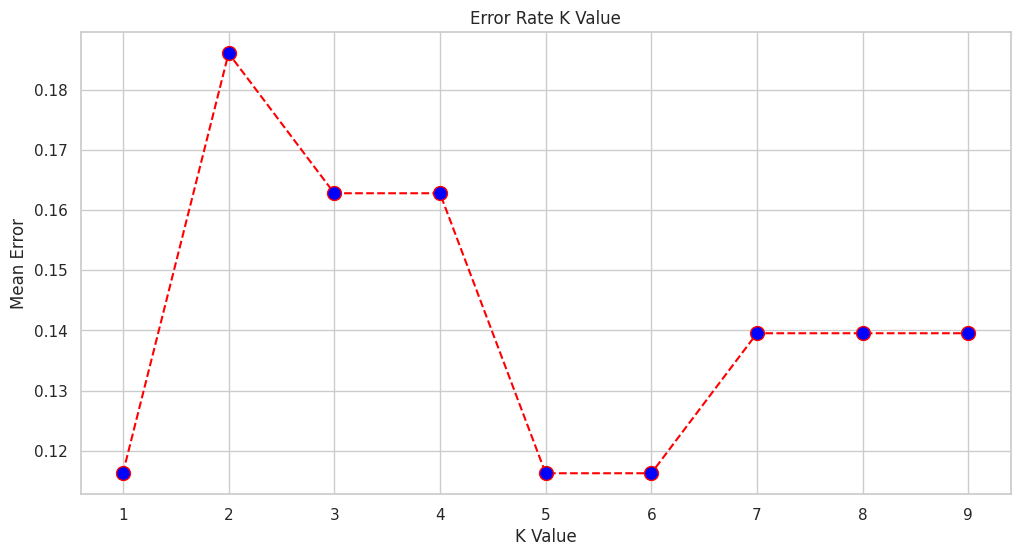

In [49]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, 10), error, color='red', linestyle='dashed', marker='o',markerfacecolor='blue', markersize=10)
plt.title('Error Rate K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [50]:
!pip install scikit-learn

In [51]:
modelo_classificador = KNeighborsClassifier(n_neighbors=5) #5 eu considerei pois era um pontos acima com menor error
modelo_classificador.fit(x_train_escalonado, y_train)

KNeighborsClassifier()

In [52]:
y_predito = modelo_classificador.predict(x_test_escalonado)

In [53]:
y_predito

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1])

In [54]:
from sklearn.metrics import accuracy_score

In [55]:
print(accuracy_score(y_test, y_predito))

0.8837209302325582


In [56]:
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC,SVC

In [57]:
svm = Pipeline([("linear_svs",LinearSVC(C=1))])
svm.fit(x_train_escalonado,y_train)

Pipeline(steps=[('linear_svs', LinearSVC(C=1))])

In [58]:
y_predito_svm = svm.predict(x_test_escalonado)

In [59]:
print(accuracy_score(y_test, y_predito_svm))

0.8604651162790697
